# 데이터 불러오기

### 문제 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ModuleNotFoundError: No module named 'pandas'

In [2]:
csv_PATH = 'A_공유자전거_cleaned.csv'
df_origin = pd.read_csv(csv_PATH)

df_origin.head()

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0


In [3]:
df = df_origin.copy()
df.shape

(652, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          652 non-null    str    
 1   station_zone       652 non-null    str    
 2   member_type        629 non-null    str    
 3   weather            635 non-null    str    
 4   temperature_c      652 non-null    float64
 5   humidity_pct       627 non-null    float64
 6   wind_speed_mps     652 non-null    float64
 7   distance_km        652 non-null    float64
 8   ride_duration_min  631 non-null    float64
 9   bike_age_months    638 non-null    float64
 10  late_return        652 non-null    int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 72.7 KB


In [5]:
df.describe(include="all")

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
count,652,652,629,635,652.000000,627.000000,652.000000,652.000000,631.000000,638.000000,652.000000
unique,644,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R0019,주거,월회원,맑음,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,192,245,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,22.854755,62.670175,3.218558,4.318466,22.682092,22.354232,0.050613
std,NaN,NaN,NaN,NaN,6.487134,15.228703,1.392390,5.384499,24.133076,10.928047,0.219375
min,NaN,NaN,NaN,NaN,-19.100000,28.000000,0.200000,0.680000,4.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,19.000000,51.750000,2.200000,2.180000,13.500000,14.000000,0.000000
50%,NaN,NaN,NaN,NaN,22.600000,61.500000,3.200000,3.280000,18.600000,22.000000,0.000000
75%,NaN,NaN,NaN,NaN,27.225000,72.100000,4.200000,4.910000,24.900000,29.000000,0.000000


In [6]:
df.isnull().sum()

rental_id             0
station_zone          0
member_type          23
weather              17
temperature_c         0
humidity_pct         25
wind_speed_mps        0
distance_km           0
ride_duration_min    21
bike_age_months      14
late_return           0
dtype: int64

In [7]:
df.isnull().mean()

rental_id            0.000000
station_zone         0.000000
member_type          0.035276
weather              0.026074
temperature_c        0.000000
humidity_pct         0.038344
wind_speed_mps       0.000000
distance_km          0.000000
ride_duration_min    0.032209
bike_age_months      0.021472
late_return          0.000000
dtype: float64

In [11]:
miss_table = pd.DataFrame({
    '결측치 개수' : df.isnull().sum(),
    '결측치 평균' : df.isnull().mean()
})
miss_table

,결측치 개수,결측치 평균
rental_id,0,0.000000
station_zone,0,0.000000
member_type,23,0.035276
weather,17,0.026074
temperature_c,0,0.000000
humidity_pct,25,0.038344
wind_speed_mps,0,0.000000
distance_km,0,0.000000
ride_duration_min,21,0.032209
bike_age_months,14,0.021472


In [12]:
df.duplicated().sum()

np.int64(6)

In [13]:
df.duplicated(subset=["rental_id"]).sum()

np.int64(8)

rental_id가 분석용 피처인지 식별자인지 판단하고 근거를 1문장으로 작성하세요.

--> 각 데이터의 행을 구별하고 추척하기 위한 고유번호이기 때문.

### 문제 2

In [15]:
df = df.drop_duplicates()

In [18]:
df_after = df.shape
df_after

(646, 11)

중복 제거 전 652  --> 중복 제거 후 646

In [20]:
df1 = df.drop_duplicates(subset=['rental_id'], keep='last')
df1

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
641,R0642,대학가,연회원,흐림,22.4,80.8,5.5,1.53,8.6,NaN,0
642,R0643,주거,월회원,맑음,31.6,64.0,3.4,3.08,17.9,27.0,0
643,R0644,대학가,일일권,맑음,20.3,56.5,3.3,4.05,23.7,1.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


In [21]:
num_cols_na = df.select_dtypes(include='number').columns
num_cols_na

Index(['temperature_c', 'humidity_pct', 'wind_speed_mps', 'distance_km',
       'ride_duration_min', 'bike_age_months', 'late_return'],
      dtype='str')

In [23]:
num_cols_na = num_cols_na[df[num_cols_na].isnull().any()]
num_cols_na

Index(['humidity_pct', 'ride_duration_min', 'bike_age_months'], dtype='str')

In [24]:
cat_cols_na = df.select_dtypes(exclude='number').columns
cat_cols_na = cat_cols_na[df[cat_cols_na].isnull().any()]
cat_cols_na

Index(['member_type', 'weather'], dtype='str')

In [ ]:
for nc in num_cols_na:
    df[nc] = df[nc].fillna(df[nc].median())
    
df.isnull().sum()

rental_id             0
station_zone          0
member_type          22
weather              17
temperature_c         0
humidity_pct          0
wind_speed_mps        0
distance_km           0
ride_duration_min     0
bike_age_months       0
late_return           0
dtype: int64

In [26]:
for cc in cat_cols_na:
    df[cc] = df[cc].fillna("미상")
df.isnull().sum()

rental_id            0
station_zone         0
member_type          0
weather              0
temperature_c        0
humidity_pct         0
wind_speed_mps       0
distance_km          0
ride_duration_min    0
bike_age_months      0
late_return          0
dtype: int64

### 문제 3

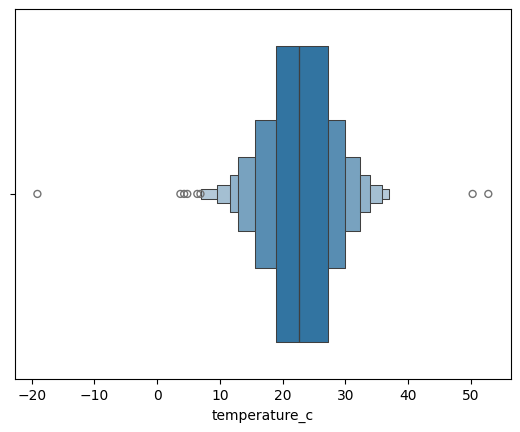

In [30]:
sns.boxenplot(x=df['temperature_c'])
plt.show()

In [34]:
# Q1 (1사분위수) 25%
q1_1 = df['temperature_c'].quantile(.25)

# Q3 (3사분위수) 75%
q3_1 = df['temperature_c'].quantile(.75)

q1_1, q3_1

(np.float64(19.0), np.float64(27.2))

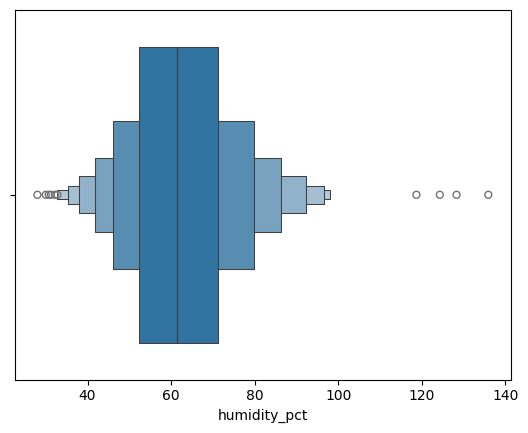

In [32]:
sns.boxenplot(x=df['humidity_pct'])
plt.show()

In [35]:
# Q1 (1사분위수) 25%
q1_2 = df['humidity_pct'].quantile(.25)

# Q3 (3사분위수) 75%
q3_2 = df['humidity_pct'].quantile(.75)

q1_2, q3_2

(np.float64(52.324999999999996), np.float64(71.3))

In [41]:
iqr = q3_2 = q1_2

lower = q1_2 - 1.5 * iqr

upper = q3_2 + 1.5 * iqr
lower, upper

(np.float64(-26.1625), np.float64(130.8125))

In [43]:
h_outlier = ((df['humidity_pct'] < 0) | df['humidity_pct'] > 100).sum()
h_outlier

np.int64(0)

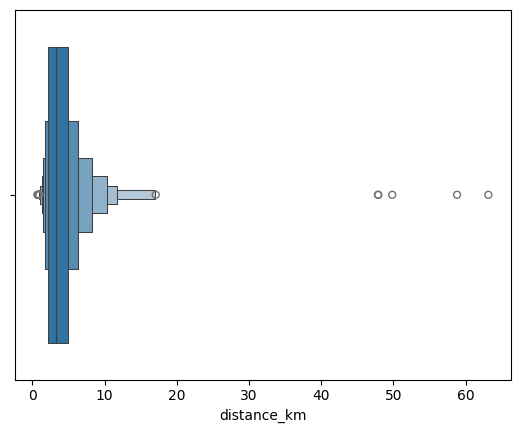

In [33]:
sns.boxenplot(x=df['distance_km'])
plt.show()

In [37]:
# Q1 (1사분위수) 25%
q1_3 = df['distance_km'].quantile(.25)

# Q3 (3사분위수) 75%
q3_3 = df['distance_km'].quantile(.75)

q1_3, q3_3

(np.float64(2.18), np.float64(4.905))

In [44]:
d_outlier = ((df['distance_km']) < 0).sum()
d_outlier

np.int64(0)

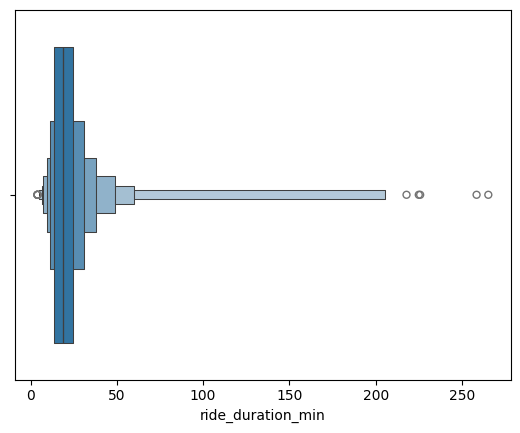

In [31]:
sns.boxenplot(x=df['ride_duration_min'])
plt.show()

In [38]:
# Q1 (1사분위수) 25%
q1_4 = df['ride_duration_min'].quantile(.25)

# Q3 (3사분위수) 75%
q3_4 = df['ride_duration_min'].quantile(.75)

q1_4, q3_4

(np.float64(13.6), np.float64(24.5))

In [47]:
r_outlier = ((df['ride_duration_min'] < 0) | (df['ride_duration_min']) > 1440).sum()
r_outlier

np.int64(0)

- temperature_c : 현실 범위 경계값으로 보정(통계적으론 드물지만 높고 낮은 온도가 나올 수도 있어서)
- humidity_pct : 행 제거 (습도가 0 이하거나 100 이상이 나올 수 없어서)
- distance_km : 원본 값 유지 + 이상치 여부 플래그 생성 (높은 값이 나올 수도 있어서)
- ride_duration_min : 원본 값 유지 + 이상치 여부 플래그 생성 ( 높은 값이 나올 수도 있어서)

## 문제 4

In [48]:
df= df_origin.copy()

In [51]:
df['bad_weather'] = np.where(df['weather'] == '비', 1, 0)

In [52]:
df[['bad_weather', 'weather']]

,bad_weather,weather
0,1,비
1,0,흐림
2,0,맑음
3,0,흐림
4,0,맑음
...,...,...
647,0,맑음
648,0,흐림
649,0,맑음
650,0,흐림


In [55]:
bamavg=df['bike_age_months'].mean()
bamavg

np.float64(22.354231974921632)

In [57]:
df['old_bike'] = np.where(df['bike_age_months'] > bamavg ,1 , 0)

In [58]:
df[['old_bike', 'bike_age_months']]

,old_bike,bike_age_months
0,1,28.0
1,1,33.0
2,1,31.0
3,0,21.0
4,1,42.0
...,...,...
647,0,13.0
648,1,28.0
649,0,3.0
650,1,37.0


In [63]:
df= df_origin.copy()

oh = OneHotEncoder()
df['member_type'].values

<ArrowStringArray>
['일일권', '월회원', '일일권', '연회원', '월회원', '월회원', '월회원', '일일권', '연회원', '연회원',
 ...
 '월회원', '일일권', '일일권', '일일권', '연회원',   nan, '월회원', '연회원', '일일권', '일일권']
Length: 652, dtype: str

In [64]:
df['member_type'].to_numpy().reshape(-1,1)

array([['일일권'],
       ['월회원'],
       ['일일권'],
       ['연회원'],
       ['월회원'],
       ['월회원'],
       ['월회원'],
       ['일일권'],
       ['연회원'],
       ['연회원'],
       ['월회원'],
       ['월회원'],
       ['연회원'],
       ['일일권'],
       ['연회원'],
       ['일일권'],
       ['일일권'],
       ['연회원'],
       ['일일권'],
       ['월회원'],
       ['월회원'],
       ['연회원'],
       ['월회원'],
       ['일일권'],
       ['연회원'],
       ['월회원'],
       ['일일권'],
       ['일일권'],
       ['일일권'],
       ['월회원'],
       ['일일권'],
       ['일일권'],
       ['월회원'],
       ['월회원'],
       ['연회원'],
       ['연회원'],
       ['월회원'],
       ['월회원'],
       ['일일권'],
       ['월회원'],
       ['일일권'],
       ['월회원'],
       ['월회원'],
       ['월회원'],
       ['월회원'],
       ['일일권'],
       ['일일권'],
       ['월회원'],
       ['월회원'],
       ['연회원'],
       ['일일권'],
       ['월회원'],
       ['월회원'],
       ['연회원'],
       ['월회원'],
       ['월회원'],
       ['월회원'],
       ['일일권'],
       ['월회원'],
       ['월회원'],
       ['월회원'],
       ['일일권'],
       [

In [67]:
oh.fit_transform(df['member_type'].to_numpy().reshape(-1,1)).toarray()

array([[0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]], shape=(652, 4))

In [68]:
oh.fit_transform(df['station_zone'].to_numpy().reshape(-1,1)).toarray()

array([[1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.]], shape=(652, 4))

In [70]:
df.columns

Index(['rental_id', 'station_zone', 'member_type', 'weather', 'temperature_c',
       'humidity_pct', 'wind_speed_mps', 'distance_km', 'ride_duration_min',
       'bike_age_months', 'late_return'],
      dtype='str')

In [75]:
scale_cols = ['temperature_c',
       'humidity_pct', 'wind_speed_mps', 'distance_km', 'ride_duration_min',
       'bike_age_months']

df[scale_cols]

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months
0,31.5,77.0,5.6,4.11,NaN,28.0
1,23.3,74.6,4.6,1.35,11.0,33.0
2,22.5,56.3,1.0,1.49,11.6,31.0
3,28.6,77.3,2.0,6.73,27.5,21.0
4,13.0,46.3,0.8,3.09,17.5,42.0
...,...,...,...,...,...,...
647,26.9,72.0,5.2,3.40,19.6,13.0
648,14.1,77.0,2.8,1.66,16.9,28.0
649,25.3,42.5,1.9,5.29,24.9,3.0
650,29.4,76.3,1.6,1.44,205.7,37.0


In [76]:
df[scale_cols].describe().loc[['mean', 'std']]

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months
mean,22.854755,62.670175,3.218558,4.318466,22.682092,22.354232
std,6.487134,15.228703,1.392390,5.384499,24.133076,10.928047


In [79]:
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df[scale_cols].describe().loc[['mean', 'std']]

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months
mean,7.628526e-17,2.493132e-16,1.457593e-16,-6.266289e-17,1.013452e-16,-1.559185e-16
std,1.000768e+00,1.000798e+00,1.000768e+00,1.000768e+00,1.000793e+00,1.000785e+00


In [80]:
df.to_csv('A_공유자전거_cleaned.csv', index=False)

In [81]:
pd.read_csv('A_공유자전거_cleaned.csv')

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,1.333699,0.941726,1.711640,-0.038746,NaN,0.517036,0
1,R0002,도심,월회원,흐림,0.068688,0.784003,0.992899,-0.551722,-0.484454,0.974934,0
2,R0003,공원,일일권,맑음,-0.054728,-0.418635,-1.594569,-0.525701,-0.459572,0.791775,0
3,R0004,공원,연회원,흐림,0.886317,0.961441,-0.875828,0.448210,0.199798,-0.124020,0
4,R0005,공원,월회원,맑음,-1.520289,-1.075814,-1.738317,-0.228324,-0.214900,1.799149,0
...,...,...,...,...,...,...,...,...,...,...,...
647,R0409,대학가,NaN,맑음,0.624058,0.613136,1.424144,-0.170707,-0.127814,-0.856656,0
648,R0513,도심,월회원,흐림,-1.350593,0.941726,-0.300835,-0.494105,-0.239782,0.517036,1
649,R0602,도심,연회원,맑음,0.377227,-1.325542,-0.947702,0.180570,0.091976,-1.772450,0
650,R0064,대학가,일일권,흐림,1.009733,0.895723,-1.163325,-0.534994,7.589712,1.341252,0


## 문제 5

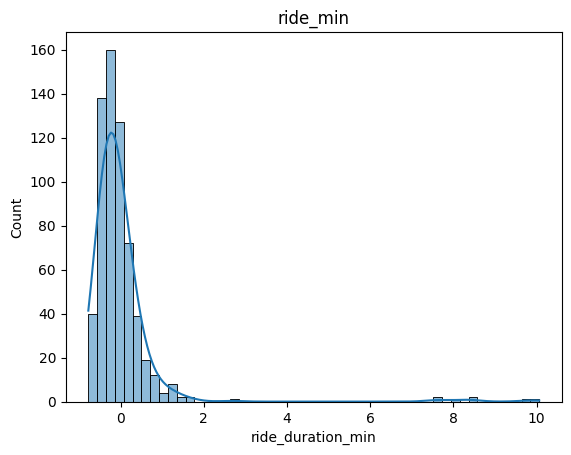

In [83]:
sns.histplot(df['ride_duration_min'], kde=True)
plt.title('ride_min')
plt.show()

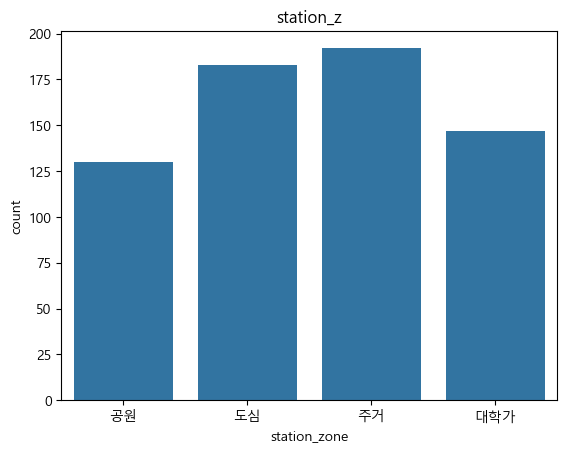

In [86]:
sns.countplot(x='station_zone', data=df)
plt.title('station_z')
plt.show()

In [2]:
git push

SyntaxError: invalid syntax (4238376967.py, line 1)